In [1]:
import matplotlib.pyplot as plt
import mplhep as hep
import pandas as pd
from PIL import Image
import importlib
import numpy as np
import awkward as ak
hep.style.use(hep.style.CMS)
import run
import mucol as mu

import imageio.v2 as imageio
from io import BytesIO
from IPython.display import Image, display

# Read parquet
simName = "TrgCenter"
data = {}
for b in run.Brange:
    B = f"{b:02d}"
    data[f"B{B}"] = ak.from_parquet(f"parquet/{simName}_B{B}.parquet")
    print(f"parquet/{simName}_B{B}.parquet was successfully added to data[B{B}]")

print("\nConverting data to an awkward array...")
data = ak.Record({
    f"B{b:02d}": data[f"B{b:02d}"]
    for b in run.Brange
})
print("Done!")

parquet/TrgCenter_B03.parquet was successfully added to data[B03]
parquet/TrgCenter_B04.parquet was successfully added to data[B04]
parquet/TrgCenter_B05.parquet was successfully added to data[B05]
parquet/TrgCenter_B06.parquet was successfully added to data[B06]
parquet/TrgCenter_B07.parquet was successfully added to data[B07]
parquet/TrgCenter_B08.parquet was successfully added to data[B08]
parquet/TrgCenter_B09.parquet was successfully added to data[B09]
parquet/TrgCenter_B10.parquet was successfully added to data[B10]

Converting data to an awkward array...
Done!


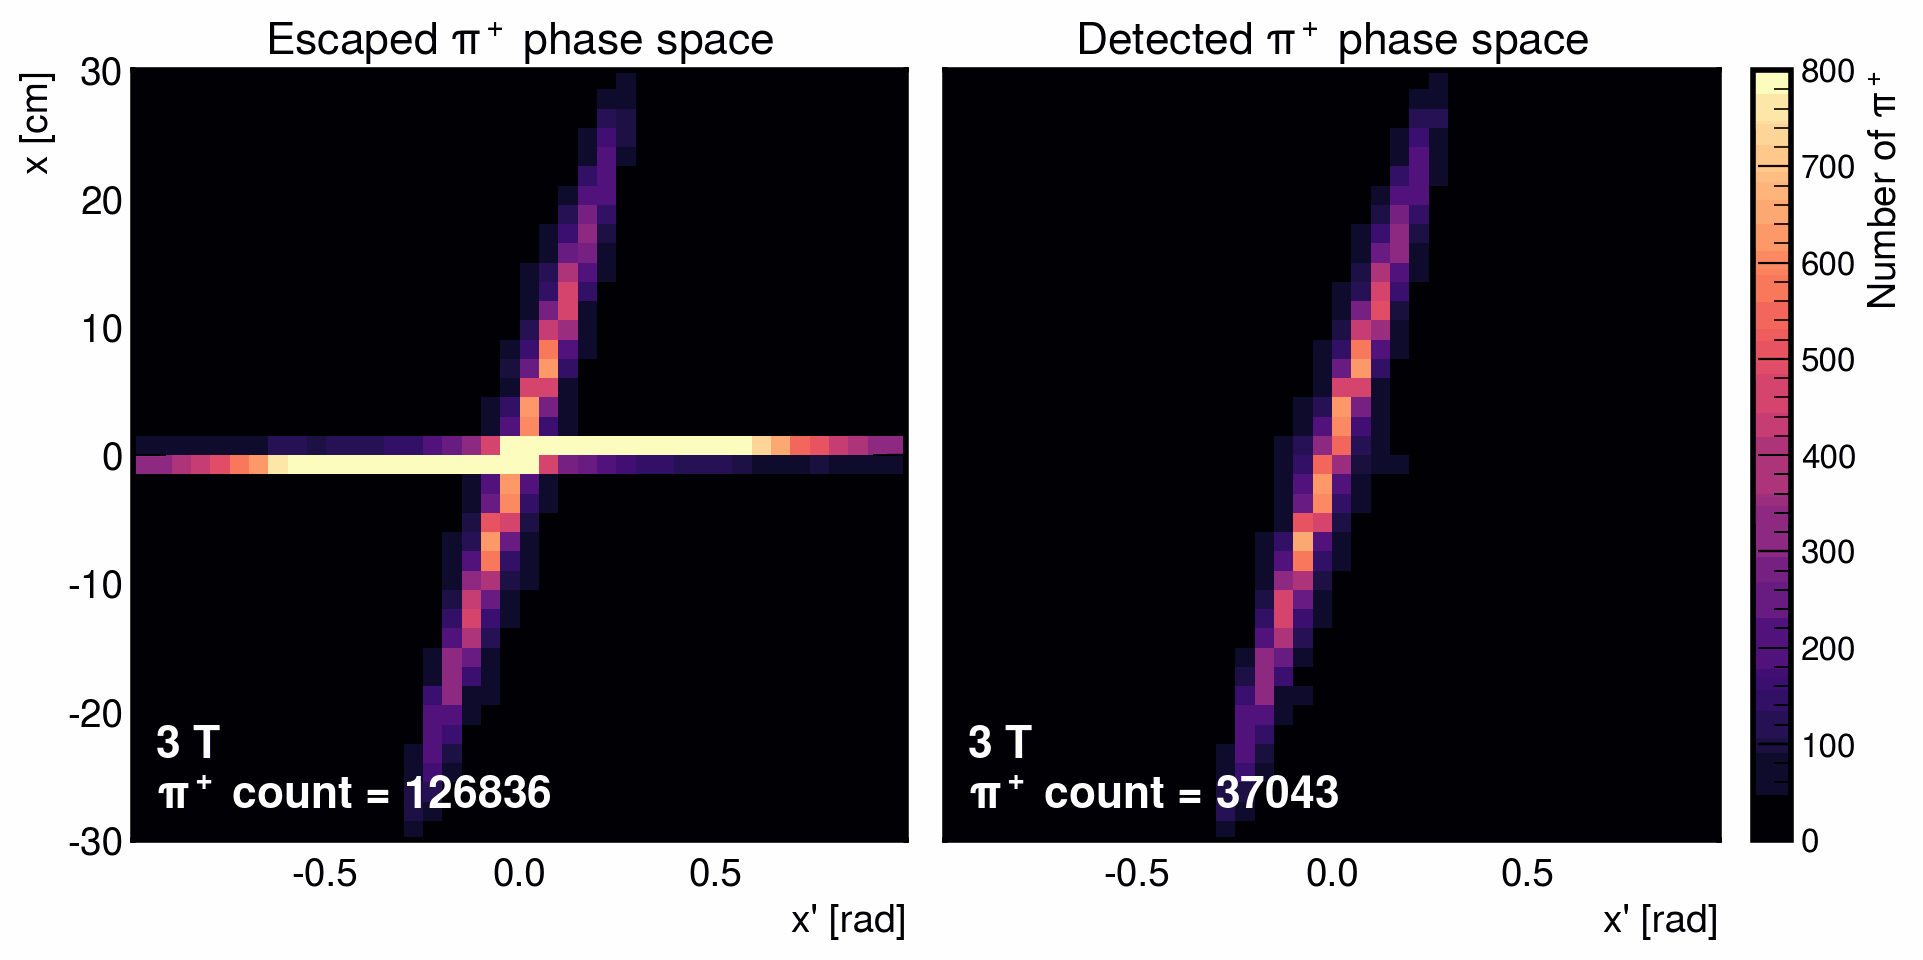

In [2]:
frames = []

for b in run.Brange:
    xbins = np.linspace(-0.99,0.99,41)
    ybins = np.linspace(-30,30,41)
    bins = [xbins, ybins]
    fig, ax = plt.subplots(1, 2, 
                           figsize=(11, 5),
                           sharey = True,
                           gridspec_kw={"wspace": 0.05})
    Bfield = f"B{b:02d}"
    esc_px = data[Bfield].esc.PiPlus.p * data[Bfield].esc.PiPlus.cx
    esc_pz = data[Bfield].esc.PiPlus.p * data[Bfield].esc.PiPlus.cz
    ax[0], h0 = mu.draw_hist2d(ax[0], 
                               ak.flatten(esc_px/esc_pz), ak.flatten(data[Bfield].esc.PiPlus.x),
                               bins,
                               vmax=800)
    det1_px = data[Bfield].det1.PiPlus.p * data[Bfield].det1.PiPlus.cx
    det1_pz = data[Bfield].det1.PiPlus.p * data[Bfield].det1.PiPlus.cz
    ax[1], h1 = mu.draw_hist2d(ax[1], 
                               ak.flatten(det1_px/det1_pz), ak.flatten(data[Bfield].det1.PiPlus.x),
                               bins,
                               vmax=800)

    cbar = fig.colorbar(
        h1[3],      # QuadMesh from the last hist2d call
        ax=ax,      # both subplots
        location="right",
        pad=0.02,
        fraction=0.05,
    )
    
    cbar.set_label(r"Number of $\pi^+$", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    ax[1].set_xlabel('x\' [rad]', fontsize=14)
    ax[0].set_xlabel('x\' [rad]', fontsize=14)
    ax[0].set_ylabel(r'x [cm]', fontsize=14)
    ax[0].set_title(rf'Escaped $\pi^+$ phase space', fontsize=16)
    ax[1].set_title(rf'Detected $\pi^+$ phase space', fontsize=16)

    ax[0].text(
        0.03, 0.03,
        f"{b} T\n" + rf"$\pi^+$ count = {ak.sum(ak.num(data[Bfield].esc.PiPlus))}",
        transform=ax[0].transAxes,
        color="white",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )
    
    ax[1].text(
        0.03, 0.03,
        f"{b} T\n" + rf"$\pi^+$ count = {ak.sum(ak.num(data[Bfield].det1.PiPlus))}",
        transform=ax[1].transAxes,
        color="white",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

    # plt.show()

    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave(
    "piplus_ps.gif",
    frames,
    duration=700,
    loop=0,
)

display(Image(filename="piplus_ps.gif"))

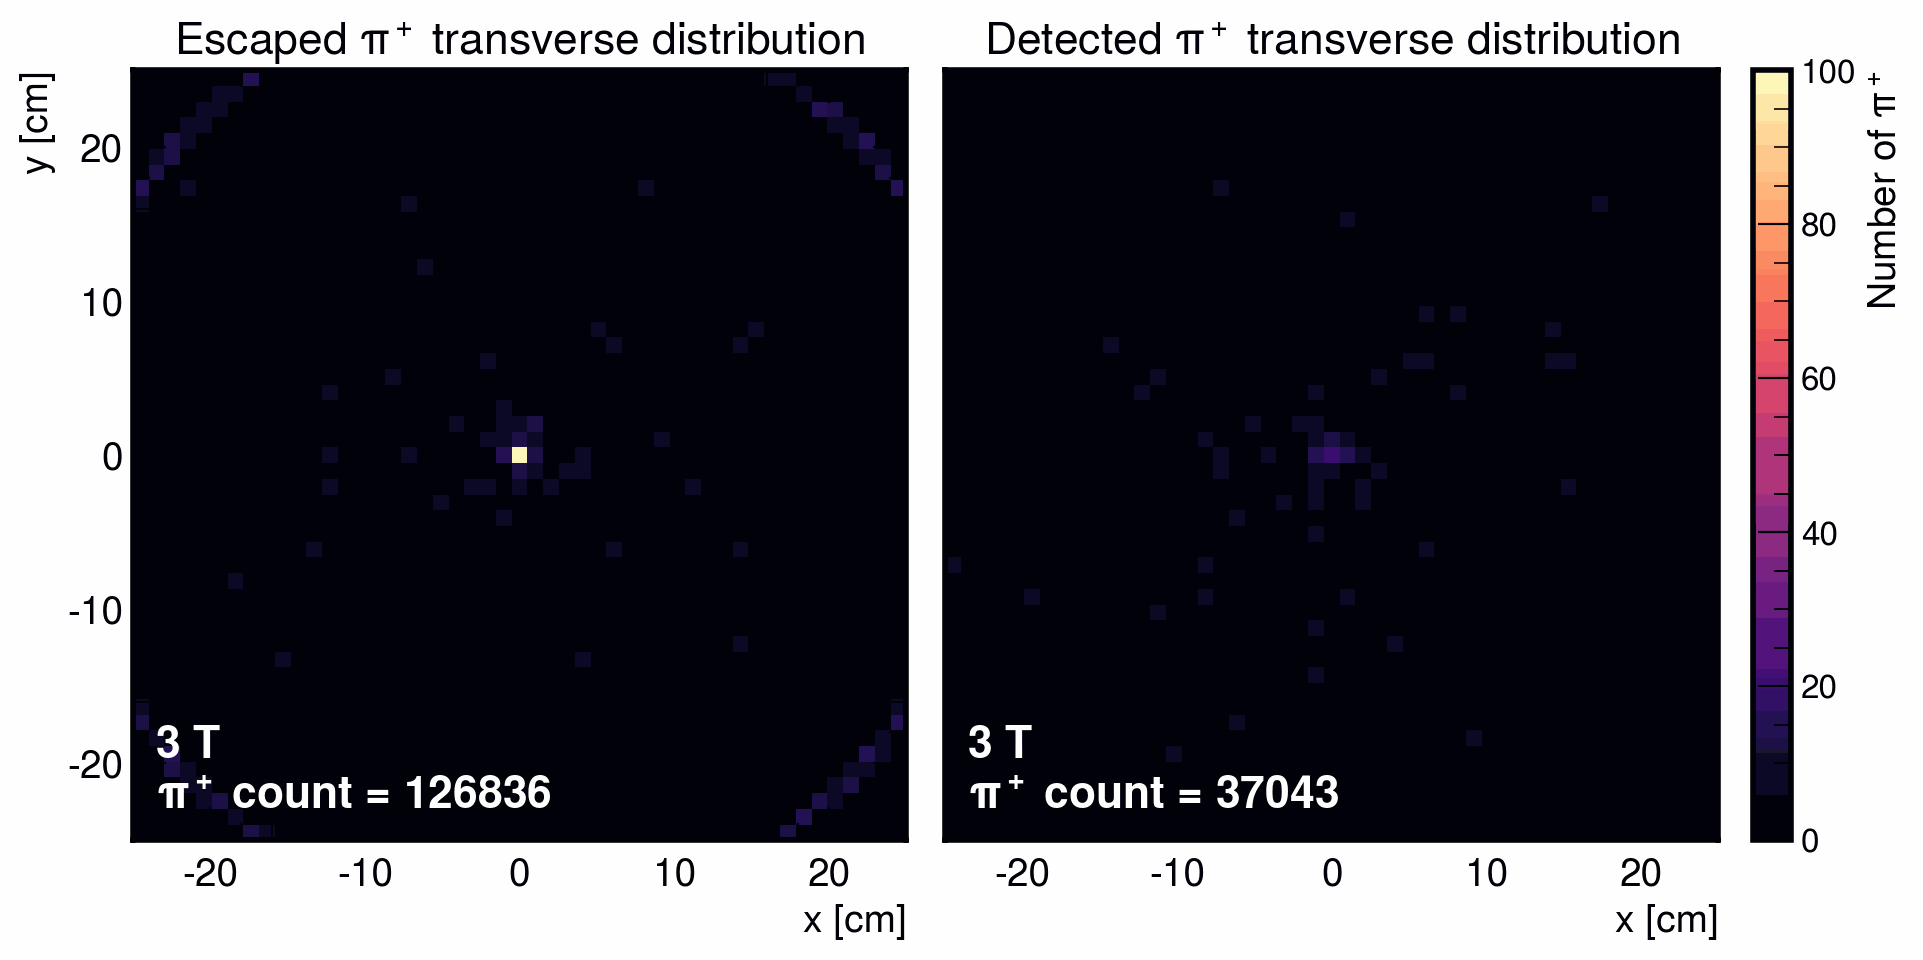

In [30]:
frames = []

for b in run.Brange:
    xbins = np.linspace(-25,25,50)
    ybins = np.linspace(-25,25,50)
    bins = [xbins, ybins]
    fig, ax = plt.subplots(1, 2, 
                           figsize=(11, 5),
                           sharey = True,
                           gridspec_kw={"wspace": 0.05})
    Bfield = f"B{b:02d}"

    esc_mom = (data[Bfield].esc.PiPlus.p >= 0.19) & (data[Bfield].esc.PiPlus.p <= 0.36)
    det1_mom = (data[Bfield].det1.PiPlus.p >= 0.19) & (data[Bfield].det1.PiPlus.p <= 0.36)

    ax[0], h0 = mu.draw_hist2d(ax[0], 
                               ak.flatten(data[Bfield].esc.PiPlus.x[esc_mom]), ak.flatten(data[Bfield].esc.PiPlus.y[esc_mom]),
                               bins,
                               vmax=100)
    det1_px = data[Bfield].det1.PiPlus.p * data[Bfield].det1.PiPlus.cx
    det1_pz = data[Bfield].det1.PiPlus.p * data[Bfield].det1.PiPlus.cz
    ax[1], h1 = mu.draw_hist2d(ax[1], 
                               ak.flatten(data[Bfield].det1.PiPlus.x[det1_mom]), ak.flatten(data[Bfield].det1.PiPlus.y[det1_mom]),
                               bins,
                               vmax=100)

    cbar = fig.colorbar(
        h1[3],      # QuadMesh from the last hist2d call
        ax=ax,      # both subplots
        location="right",
        pad=0.02,
        fraction=0.05,
    )
    
    cbar.set_label(r"Number of $\pi^+$", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    ax[1].set_xlabel('x [cm]', fontsize=14)
    ax[0].set_xlabel('x [cm]', fontsize=14)
    ax[0].set_ylabel('y [cm]', fontsize=14)
    ax[0].set_title(rf'Escaped $\pi^+$ transverse distribution', fontsize=16)
    ax[1].set_title(rf'Detected $\pi^+$ transverse distribution', fontsize=16)

    ax[0].text(
        0.03, 0.03,
        f"{b} T\n" + rf"$\pi^+$ count = {ak.sum(ak.num(data[Bfield].esc.PiPlus))}",
        transform=ax[0].transAxes,
        color="white",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )
    
    ax[1].text(
        0.03, 0.03,
        f"{b} T\n" + rf"$\pi^+$ count = {ak.sum(ak.num(data[Bfield].det1.PiPlus))}",
        transform=ax[1].transAxes,
        color="white",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

    # plt.show()

    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave(
    "piplus_xy.gif",
    frames,
    duration=700,
    loop=0,
)

display(Image(filename="piplus_xy.gif"))

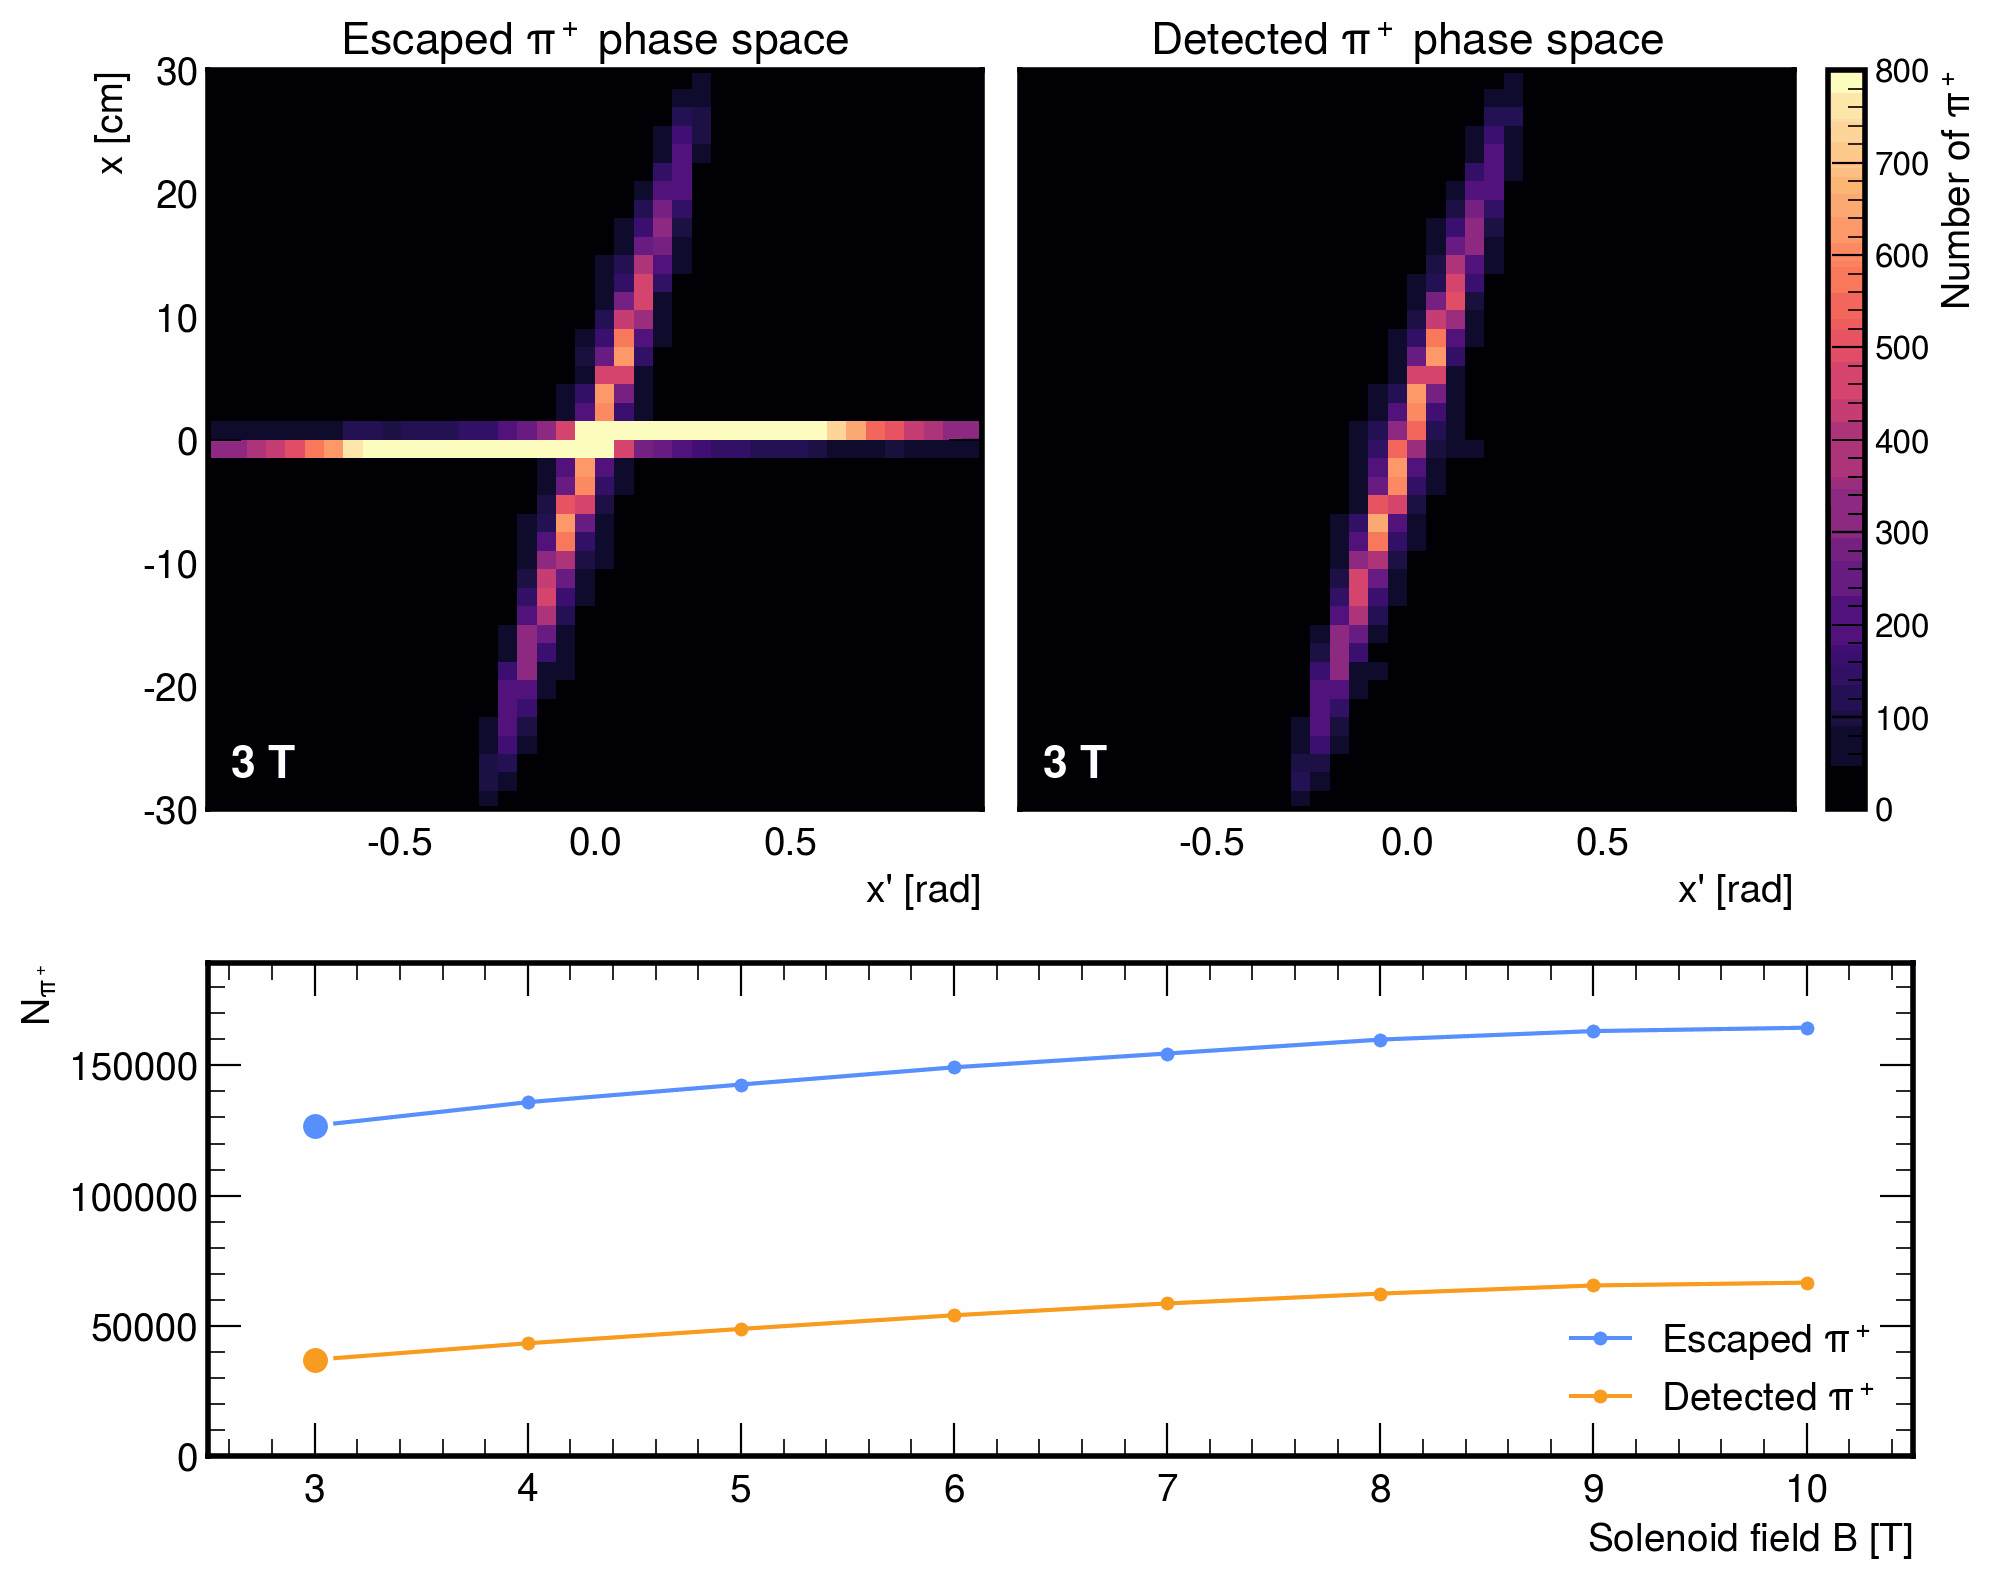

In [3]:
frames = []

B_values = []
esc_counts = []
det_counts = []

# --------------------
# Count history lists
# --------------------
for b in run.Brange:
    Bfield = f"B{b:02d}"
    B_values.append(b)
    esc_counts.append(ak.sum(ak.num(data[Bfield].esc.PiPlus)))
    det_counts.append(ak.sum(ak.num(data[Bfield].det1.PiPlus)))

# --------------------
# B loop
# --------------------
for i, b in enumerate(run.Brange):
    Bfield = f"B{b:02d}"
    xbins = np.linspace(-0.99,0.99,41)
    ybins = np.linspace(-30,30,41)
    bins = [xbins, ybins]

    fig = plt.figure(figsize=(11, 9))
    gs = fig.add_gridspec(
        2, 2,
        height_ratios=[6,4],
        hspace=0.25,
        wspace=0.05
    )

    ax0 = fig.add_subplot(gs[0,0])
    ax1 = fig.add_subplot(gs[0,1], sharey=ax0)
    ax = [ax0, ax1]
    
    ax_count = fig.add_subplot(gs[1,:])
    
    # --------------------
    # 2d histograms
    # --------------------
    esc_mom = (data[Bfield].esc.PiPlus.p >= 0.19) & (data[Bfield].esc.PiPlus.p <= 0.36)
    det1_mom = (data[Bfield].det1.PiPlus.p >= 0.19) & (data[Bfield].det1.PiPlus.p <= 0.36)
    
    esc_px = data[Bfield].esc.PiPlus.p * data[Bfield].esc.PiPlus.cx
    esc_pz = data[Bfield].esc.PiPlus.p * data[Bfield].esc.PiPlus.cz
    
    ax[0], h0 = mu.draw_hist2d(ax[0], 
                               ak.flatten(esc_px/esc_pz), ak.flatten(data[Bfield].esc.PiPlus.x),
                               bins,
                               vmax=800)
    det1_px = data[Bfield].det1.PiPlus.p * data[Bfield].det1.PiPlus.cx
    det1_pz = data[Bfield].det1.PiPlus.p * data[Bfield].det1.PiPlus.cz
    ax[1], h1 = mu.draw_hist2d(ax[1], 
                               ak.flatten(det1_px/det1_pz), ak.flatten(data[Bfield].det1.PiPlus.x),
                               bins,
                               vmax=800)

    cbar = fig.colorbar(
        h1[3],      # QuadMesh from the last hist2d call
        ax=ax,      # both subplots
        location="right",
        pad=0.02,
        fraction=0.05,
    )
    
    cbar.set_label(r"Number of $\pi^+$", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    ax[1].set_xlabel('x\' [rad]', fontsize=14)
    ax[0].set_xlabel('x\' [rad]', fontsize=14)
    ax[0].set_ylabel(r'x [cm]', fontsize=14)
    ax[1].tick_params(axis='y', labelleft=False)
    ax[0].set_title(rf'Escaped $\pi^+$ phase space', fontsize=16)
    ax[1].set_title(rf'Detected $\pi^+$ phase space', fontsize=16)

    ax[0].text(
        0.03, 0.03,
        f"{b} T",
        transform=ax[0].transAxes,
        color="white", fontsize=16, fontweight="bold",
        ha="left", va="bottom",
    )
    
    ax[1].text(
        0.03, 0.03,
        f"{b} T",
        transform=ax[1].transAxes,
        color="white", fontsize=16, fontweight="bold", 
        ha="left", va="bottom",
    )

    # --------------------
    # full count history
    # --------------------
    ax_count.plot(
        B_values, esc_counts,
        "-o", markersize=4,
        label=r"Escaped $\pi^+$"
    )

    ax_count.plot(
        B_values, det_counts,
        "-o", markersize=4,
        label=r"Detected $\pi^+$"
    )


    # highlighted current point
    ax_count.scatter(
        b, esc_counts[i],
        s=120, edgecolor="white", linewidth=2,
        zorder=5
    )

    ax_count.scatter(
        b, det_counts[i],
        s=120, edgecolor="white", linewidth=2,
        zorder=5
    )

    ax_count.set_xlim(2.5, 10.5)
    ax_count.set_ylim(0, max(det_counts + esc_counts)*1.15)

    ax_count.set_xlabel("Solenoid field $B$ [T]", fontsize=14)
    ax_count.set_ylabel(r"$N_{\pi^+}$", fontsize=14)
    ax_count.tick_params(axis='both', labelsize=14)
    ax_count.legend(fontsize=14)


    # --------------------
    # convert to gif
    # --------------------
    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave(
    "piplus_ps&count.gif",
    frames,
    duration=700,
    loop=0,
)

display(Image(filename="piplus_ps&count.gif"))

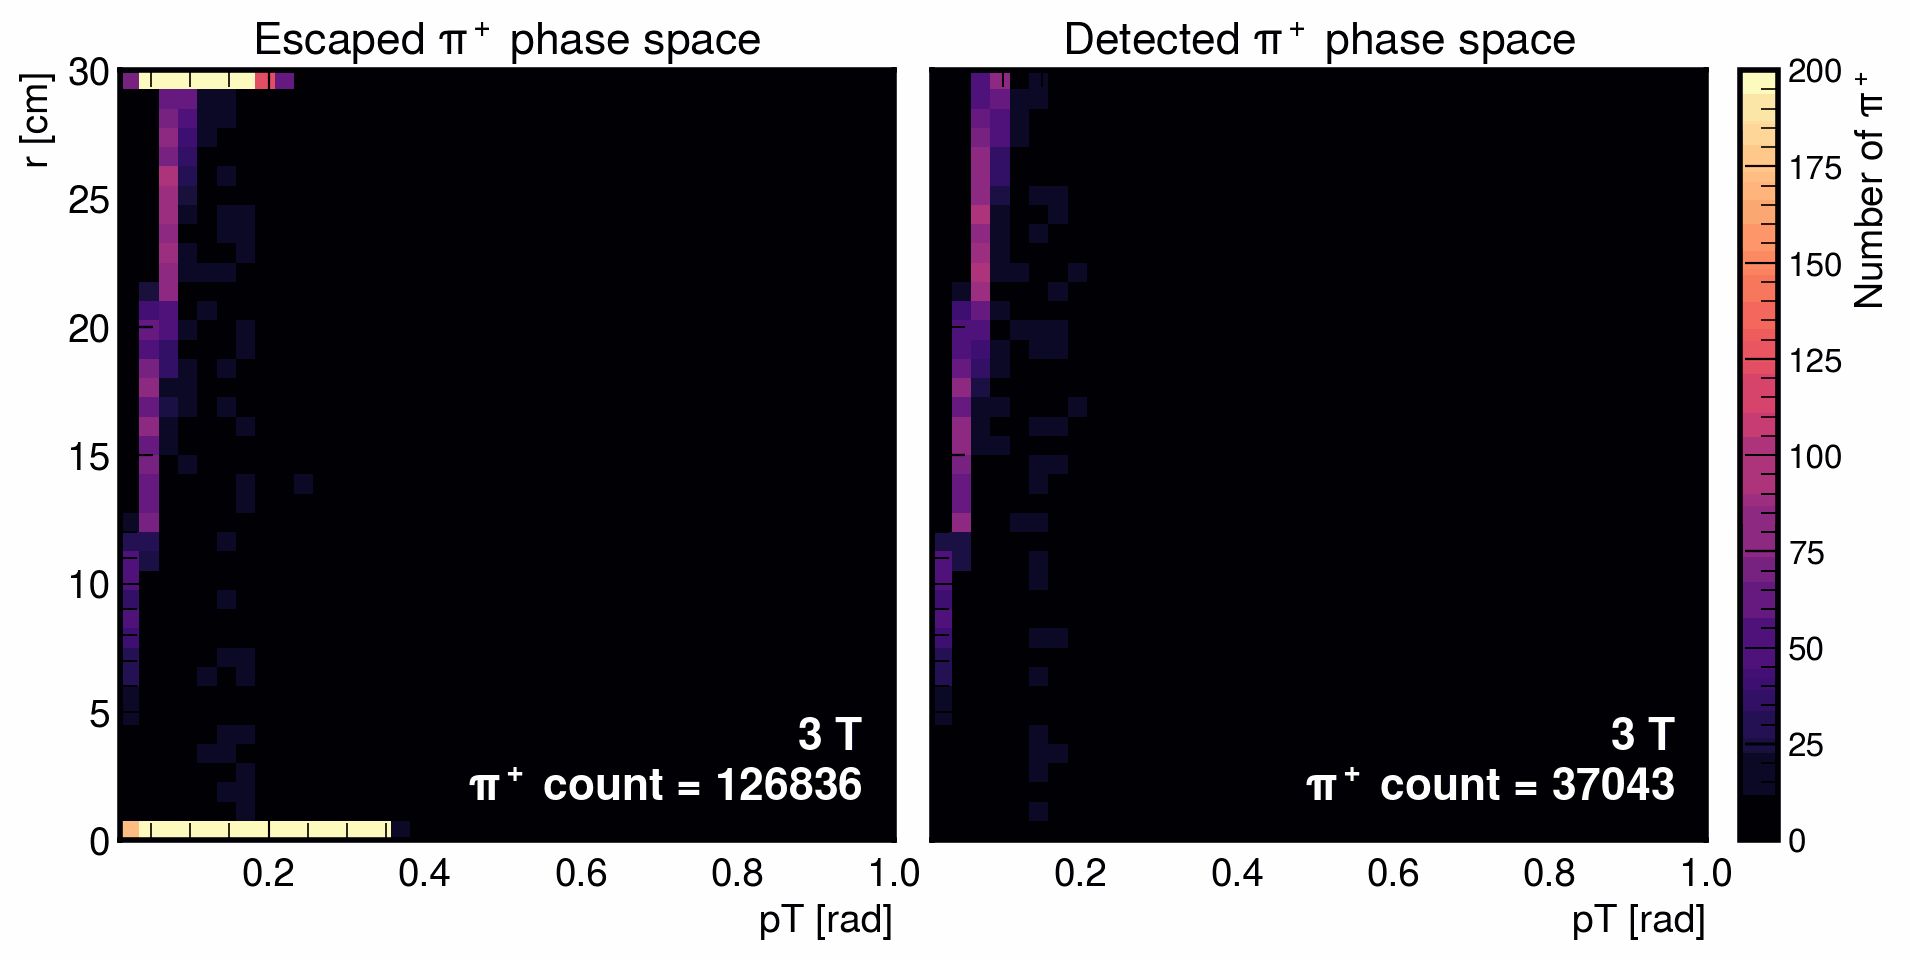

In [24]:
frames = []

for b in run.Brange:
    xbins = np.linspace(0.01,1,41)
    ybins = np.linspace(0,30,41)
    bins = [xbins, ybins]
    fig, ax = plt.subplots(1, 2, 
                           figsize=(11, 5),
                           sharey = True,
                           gridspec_kw={"wspace": 0.05})
    
    Bfield = f"B{b:02d}"
    
    esc_mom = (data[Bfield].esc.PiPlus.p >= 0.19) & (data[Bfield].esc.PiPlus.p <= 0.36)
    det1_mom = (data[Bfield].det1.PiPlus.p >= 0.19) & (data[Bfield].det1.PiPlus.p <= 0.36)
    
    esc_r = np.sqrt(data[Bfield].esc.PiPlus.x**2 + data[Bfield].esc.PiPlus.y**2)
    esc_pT = data[Bfield].esc.PiPlus.p * np.sqrt(data[Bfield].esc.PiPlus.cx**2 + data[Bfield].esc.PiPlus.cy**2)
    
    ax[0], h0 = mu.draw_hist2d(ax[0], 
                               ak.flatten(esc_pT[esc_mom]), ak.flatten(esc_r[esc_mom]),
                               bins,
                               vmax=200)
    
    det1_r = np.sqrt(data[Bfield].det1.PiPlus.x**2 + data[Bfield].det1.PiPlus.y**2)
    det1_pT = data[Bfield].det1.PiPlus.p * np.sqrt(data[Bfield].det1.PiPlus.cx**2 + data[Bfield].det1.PiPlus.cy**2)
    
    ax[1], h1 = mu.draw_hist2d(ax[1], 
                               ak.flatten(det1_pT[det1_mom]), ak.flatten(det1_r[det1_mom]),
                               bins,
                               vmax=200)

    cbar = fig.colorbar(
        h1[3],      # QuadMesh from the last hist2d call
        ax=ax,      # both subplots
        location="right",
        pad=0.02,
        fraction=0.05,
    )
    
    cbar.set_label(r"Number of $\pi^+$", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    ax[1].set_xlabel('pT [rad]', fontsize=14)
    ax[0].set_xlabel('pT [rad]', fontsize=14)
    ax[0].set_ylabel(r'r [cm]', fontsize=14)
    ax[0].set_title(rf'Escaped $\pi^+$ phase space', fontsize=16)
    ax[1].set_title(rf'Detected $\pi^+$ phase space', fontsize=16)

    ax[0].text(
        0.96, 0.04,
        f"{b} T\n" + rf"$\pi^+$ count = {ak.sum(ak.num(data[Bfield].esc.PiPlus))}",
        transform=ax[0].transAxes,
        color="white",
        fontsize=16,
        fontweight="bold",
        ha="right",
        va="bottom",
    )
    
    ax[1].text(
        0.96, 0.04,
        f"{b} T\n" + rf"$\pi^+$ count = {ak.sum(ak.num(data[Bfield].det1.PiPlus))}",
        transform=ax[1].transAxes,
        color="white",
        fontsize=16,
        fontweight="bold",
        ha="right",
        va="bottom",
    )

    # plt.show()

    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave(
    "piplus_rpT.gif",
    frames,
    duration=700,
    loop=0,
)

display(Image(filename="piplus_rpT.gif"))

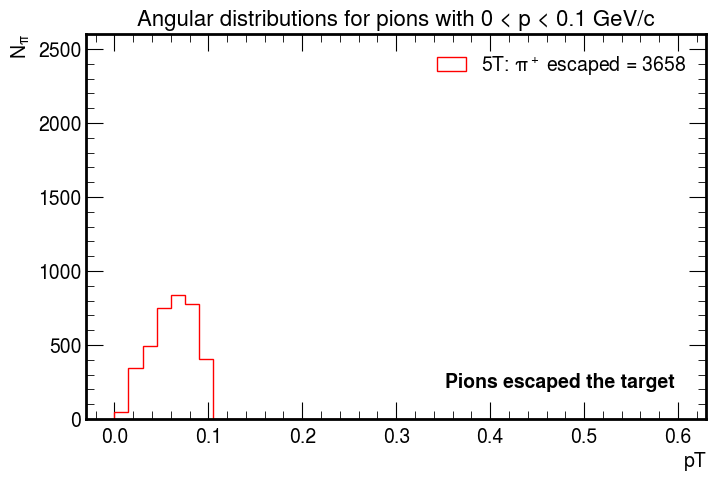

<Figure size 1000x1000 with 0 Axes>

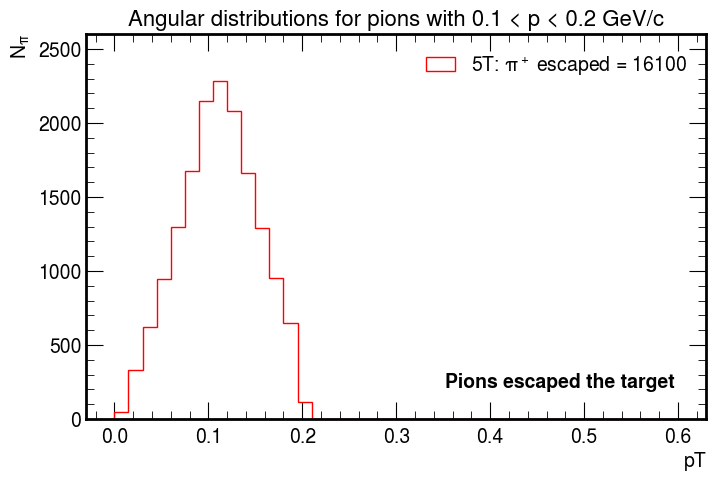

<Figure size 1000x1000 with 0 Axes>

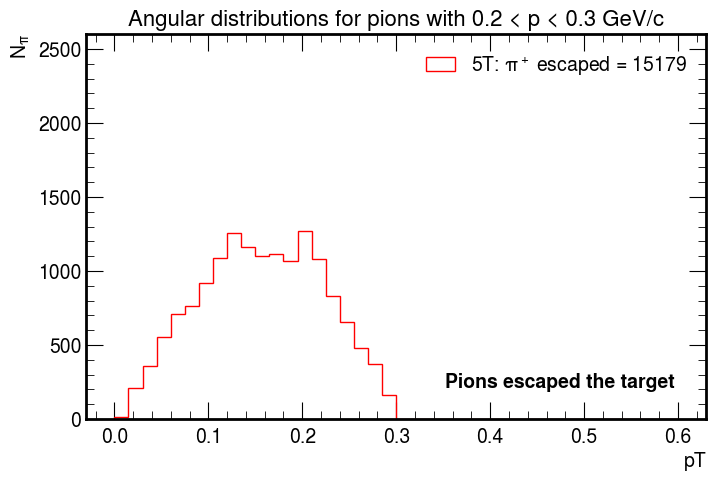

<Figure size 1000x1000 with 0 Axes>

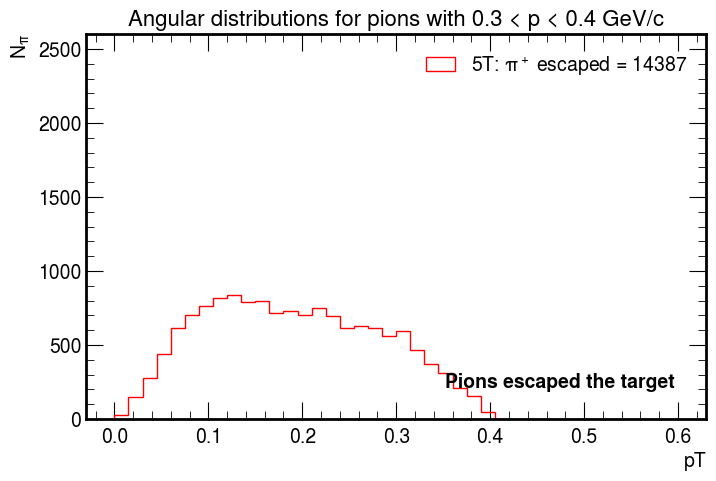

<Figure size 1000x1000 with 0 Axes>

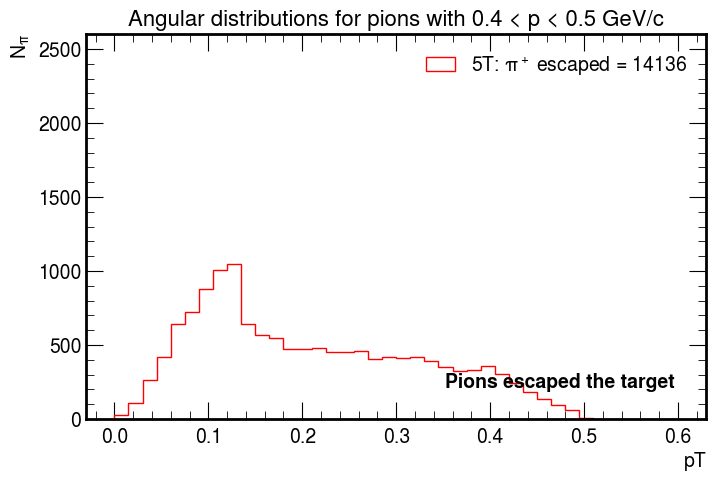

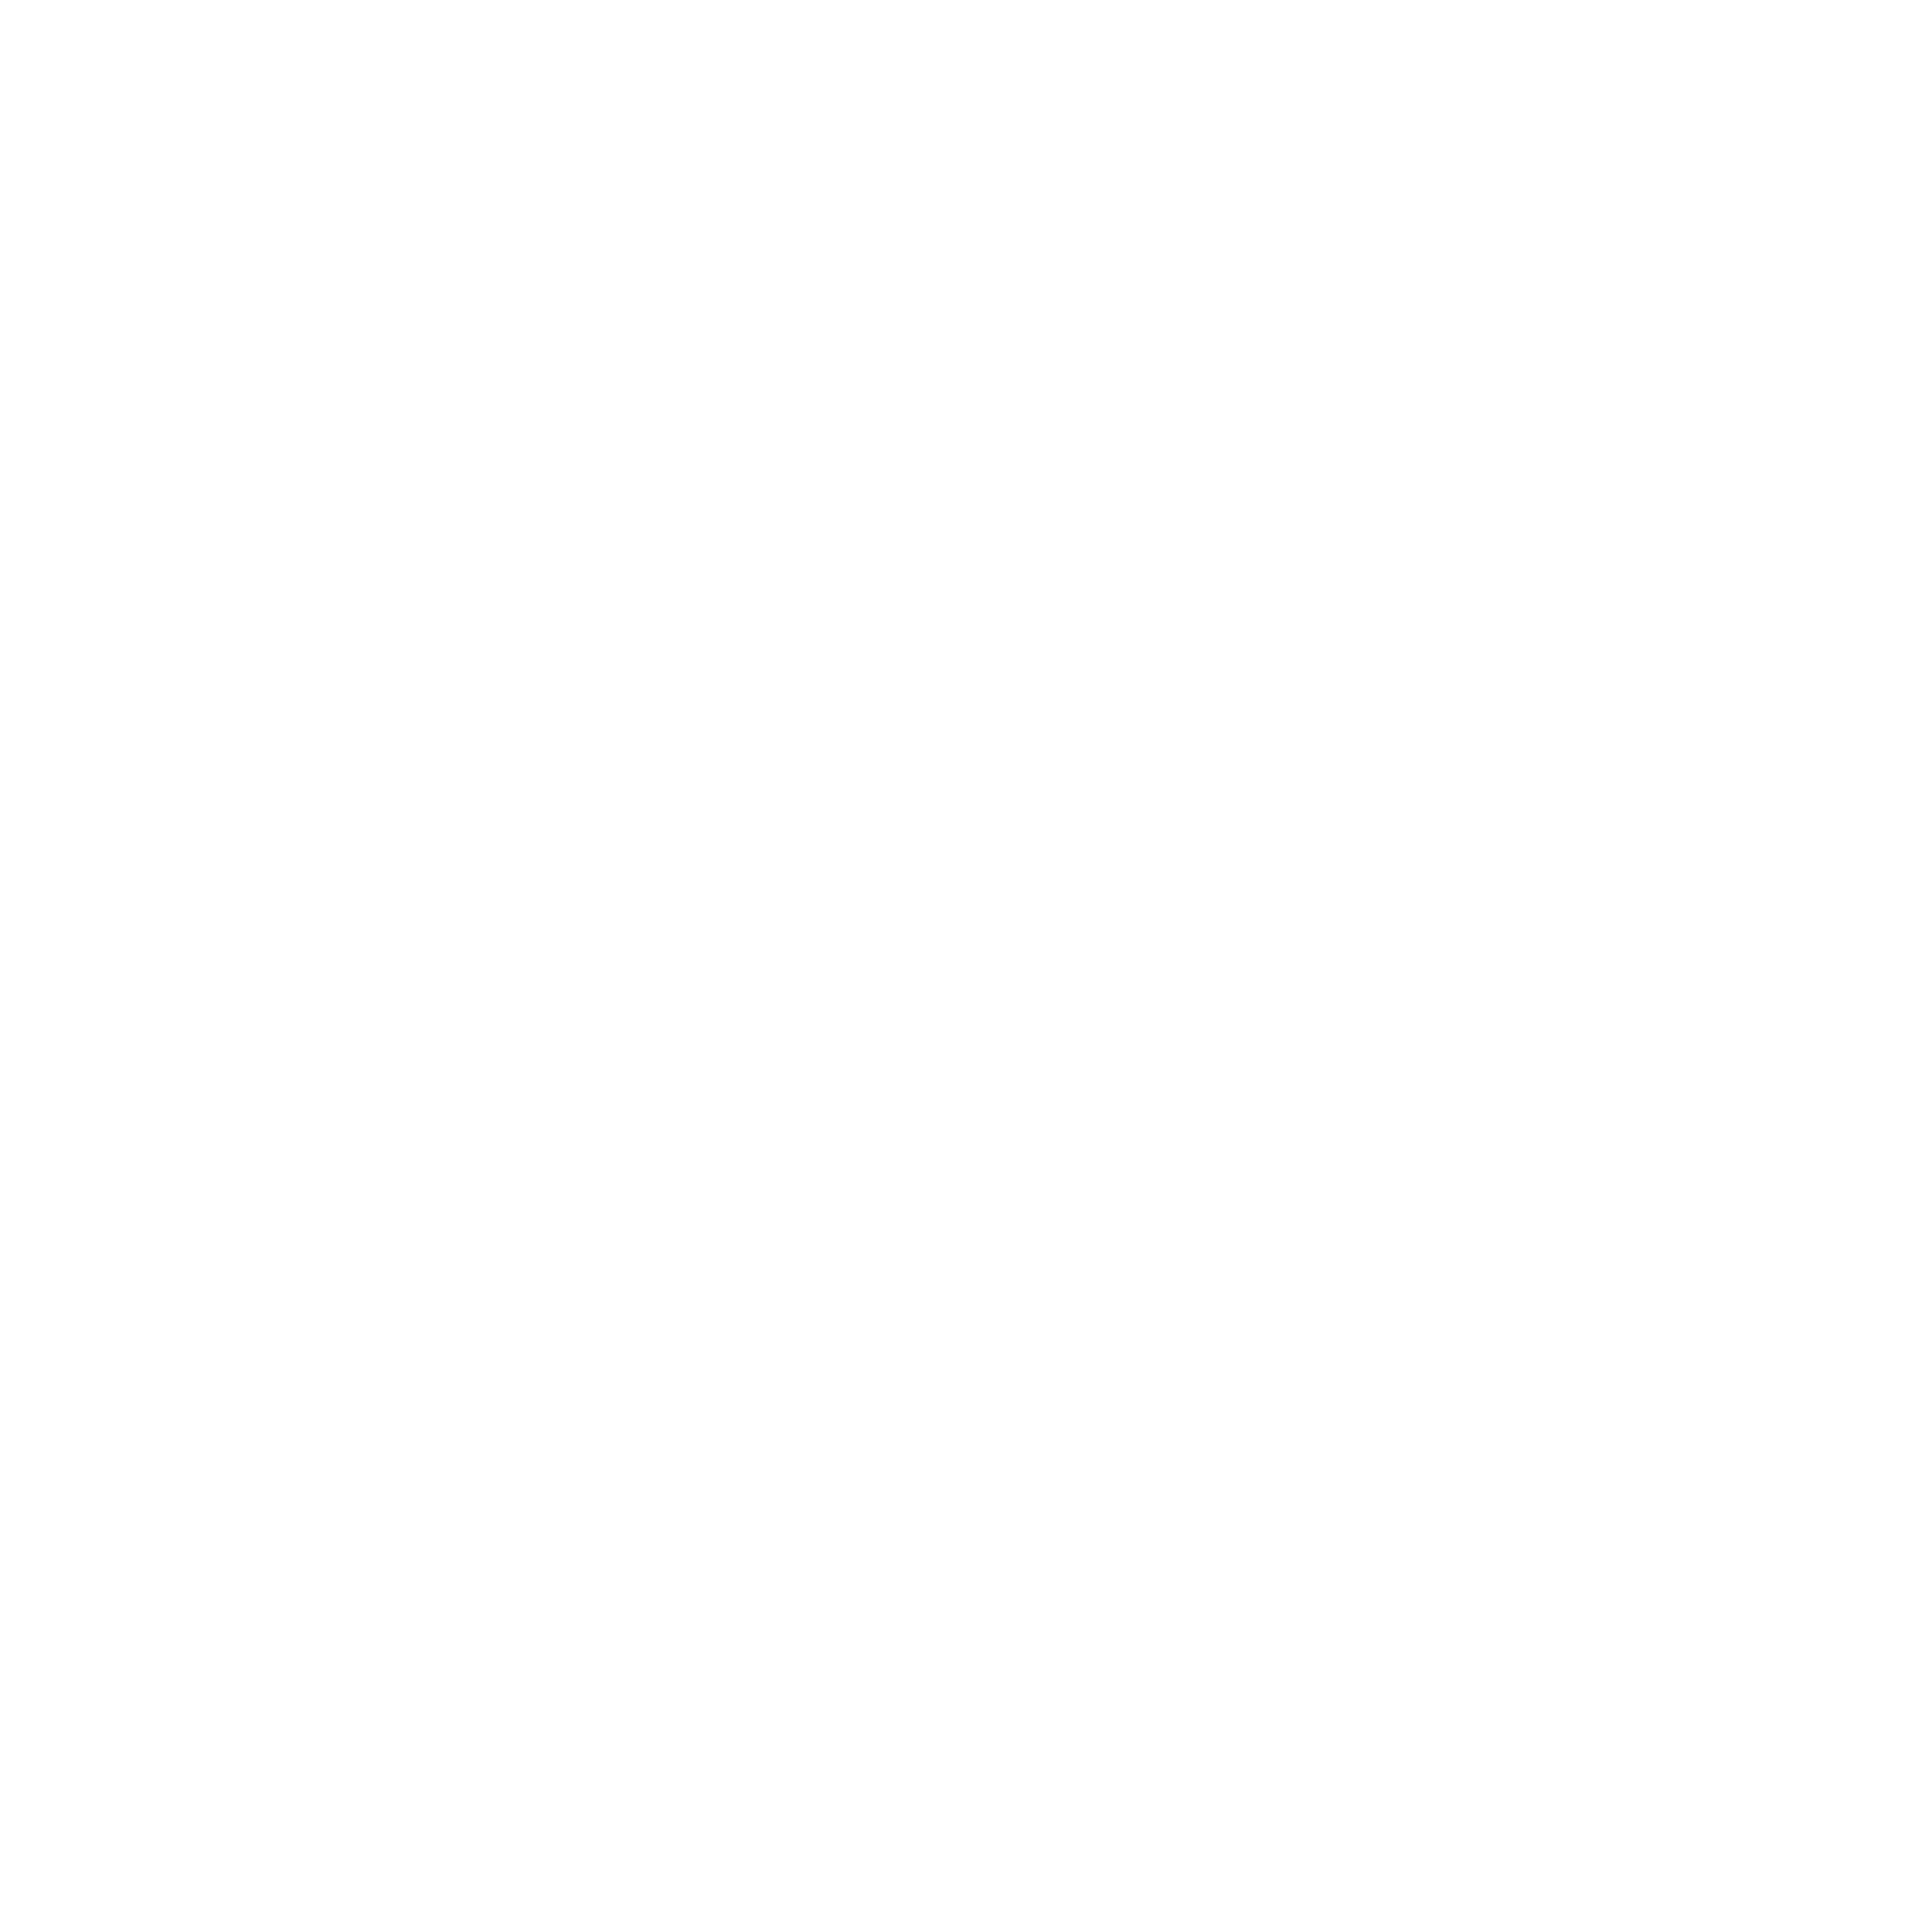

<Figure size 1000x1000 with 0 Axes>

In [2]:
p_range = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
lower = 0.4
upper = 0.5

frames = []

for i in range(len(p_range)-1):
    bins = np.linspace(0,0.6,41)
    fig, ax = plt.subplots(1, 1, 
                           figsize=(8, 5))
                           # sharex = True,
                           # gridspec_kw={"hspace": 0.05})

    Bfield = f"B05"
    p_lower = p_range[i]
    p_upper = p_range[i+1]
    esc_mom = (data[Bfield].esc.PiPlus.p >= p_lower) & (data[Bfield].esc.PiPlus.p <= p_upper)
    esc_cT = np.sqrt(data[Bfield].esc.PiPlus.cx**2 + data[Bfield].esc.PiPlus.cy**2)
    # det1_mom = (data[Bfield].det1.PiPlus.p >= p_lower) & (data[Bfield].det1.PiPlus.p <= p_upper)
    
    ax = mu.draw_hist(ax, 
                     ak.flatten(data[Bfield].esc.PiPlus.p[esc_mom] * esc_cT[esc_mom]), bins,
                     f'5T: $\\pi^+$ escaped = {ak.count(data[Bfield].esc.PiPlus.cz[esc_mom])}',
                     color = run.COLOR_MAP[Bfield])

    # ax[1].set_yscale("log")
    ax.set_xlabel('pT', fontsize=14)
    ax.set_ylabel(r'$N_{\pi}$', fontsize=14)
    
    ax.set_ylim(0,2600)
    
    ax.set_title(f'Angular distributions for pions with {p_lower} < p < {p_upper} GeV/c', fontsize=16)
    
    ax.text(
        0.95, 0.07,
        "Pions escaped the target",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        ha="right",
        va="bottom"
    )
    plt.show()

    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave(
    "piplus_pT.gif",
    frames,
    duration=1000,
    loop=0,
)

display(Image(filename="piplus_pT.gif"))

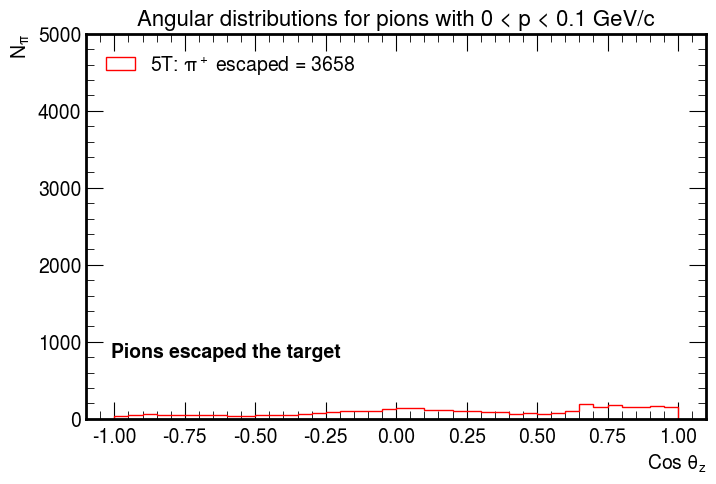

<Figure size 1000x1000 with 0 Axes>

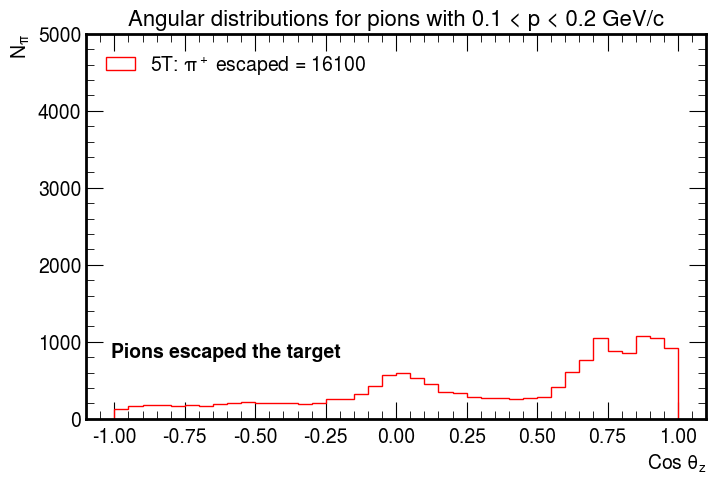

<Figure size 1000x1000 with 0 Axes>

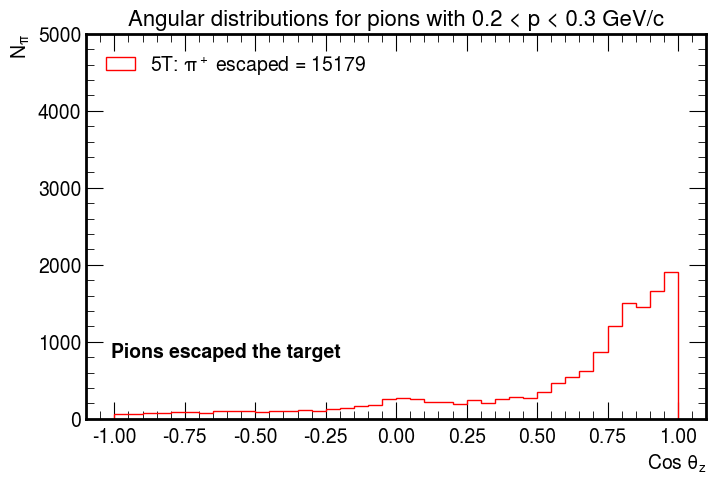

<Figure size 1000x1000 with 0 Axes>

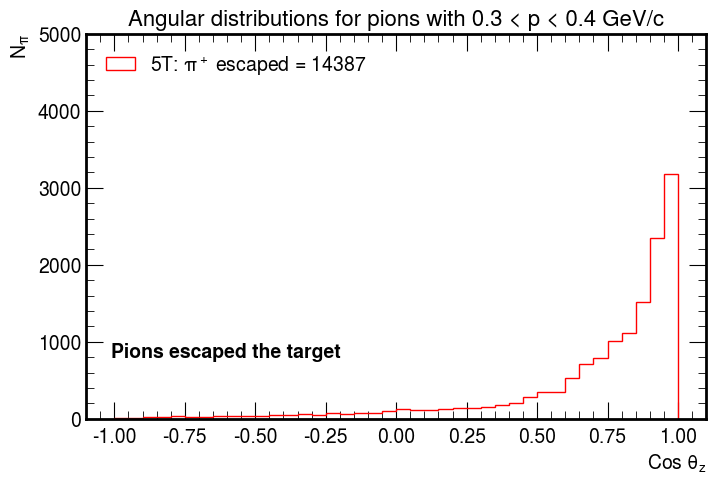

<Figure size 1000x1000 with 0 Axes>

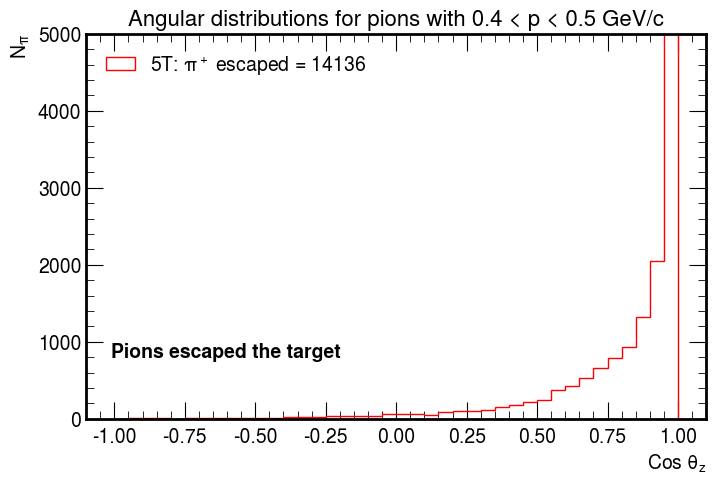

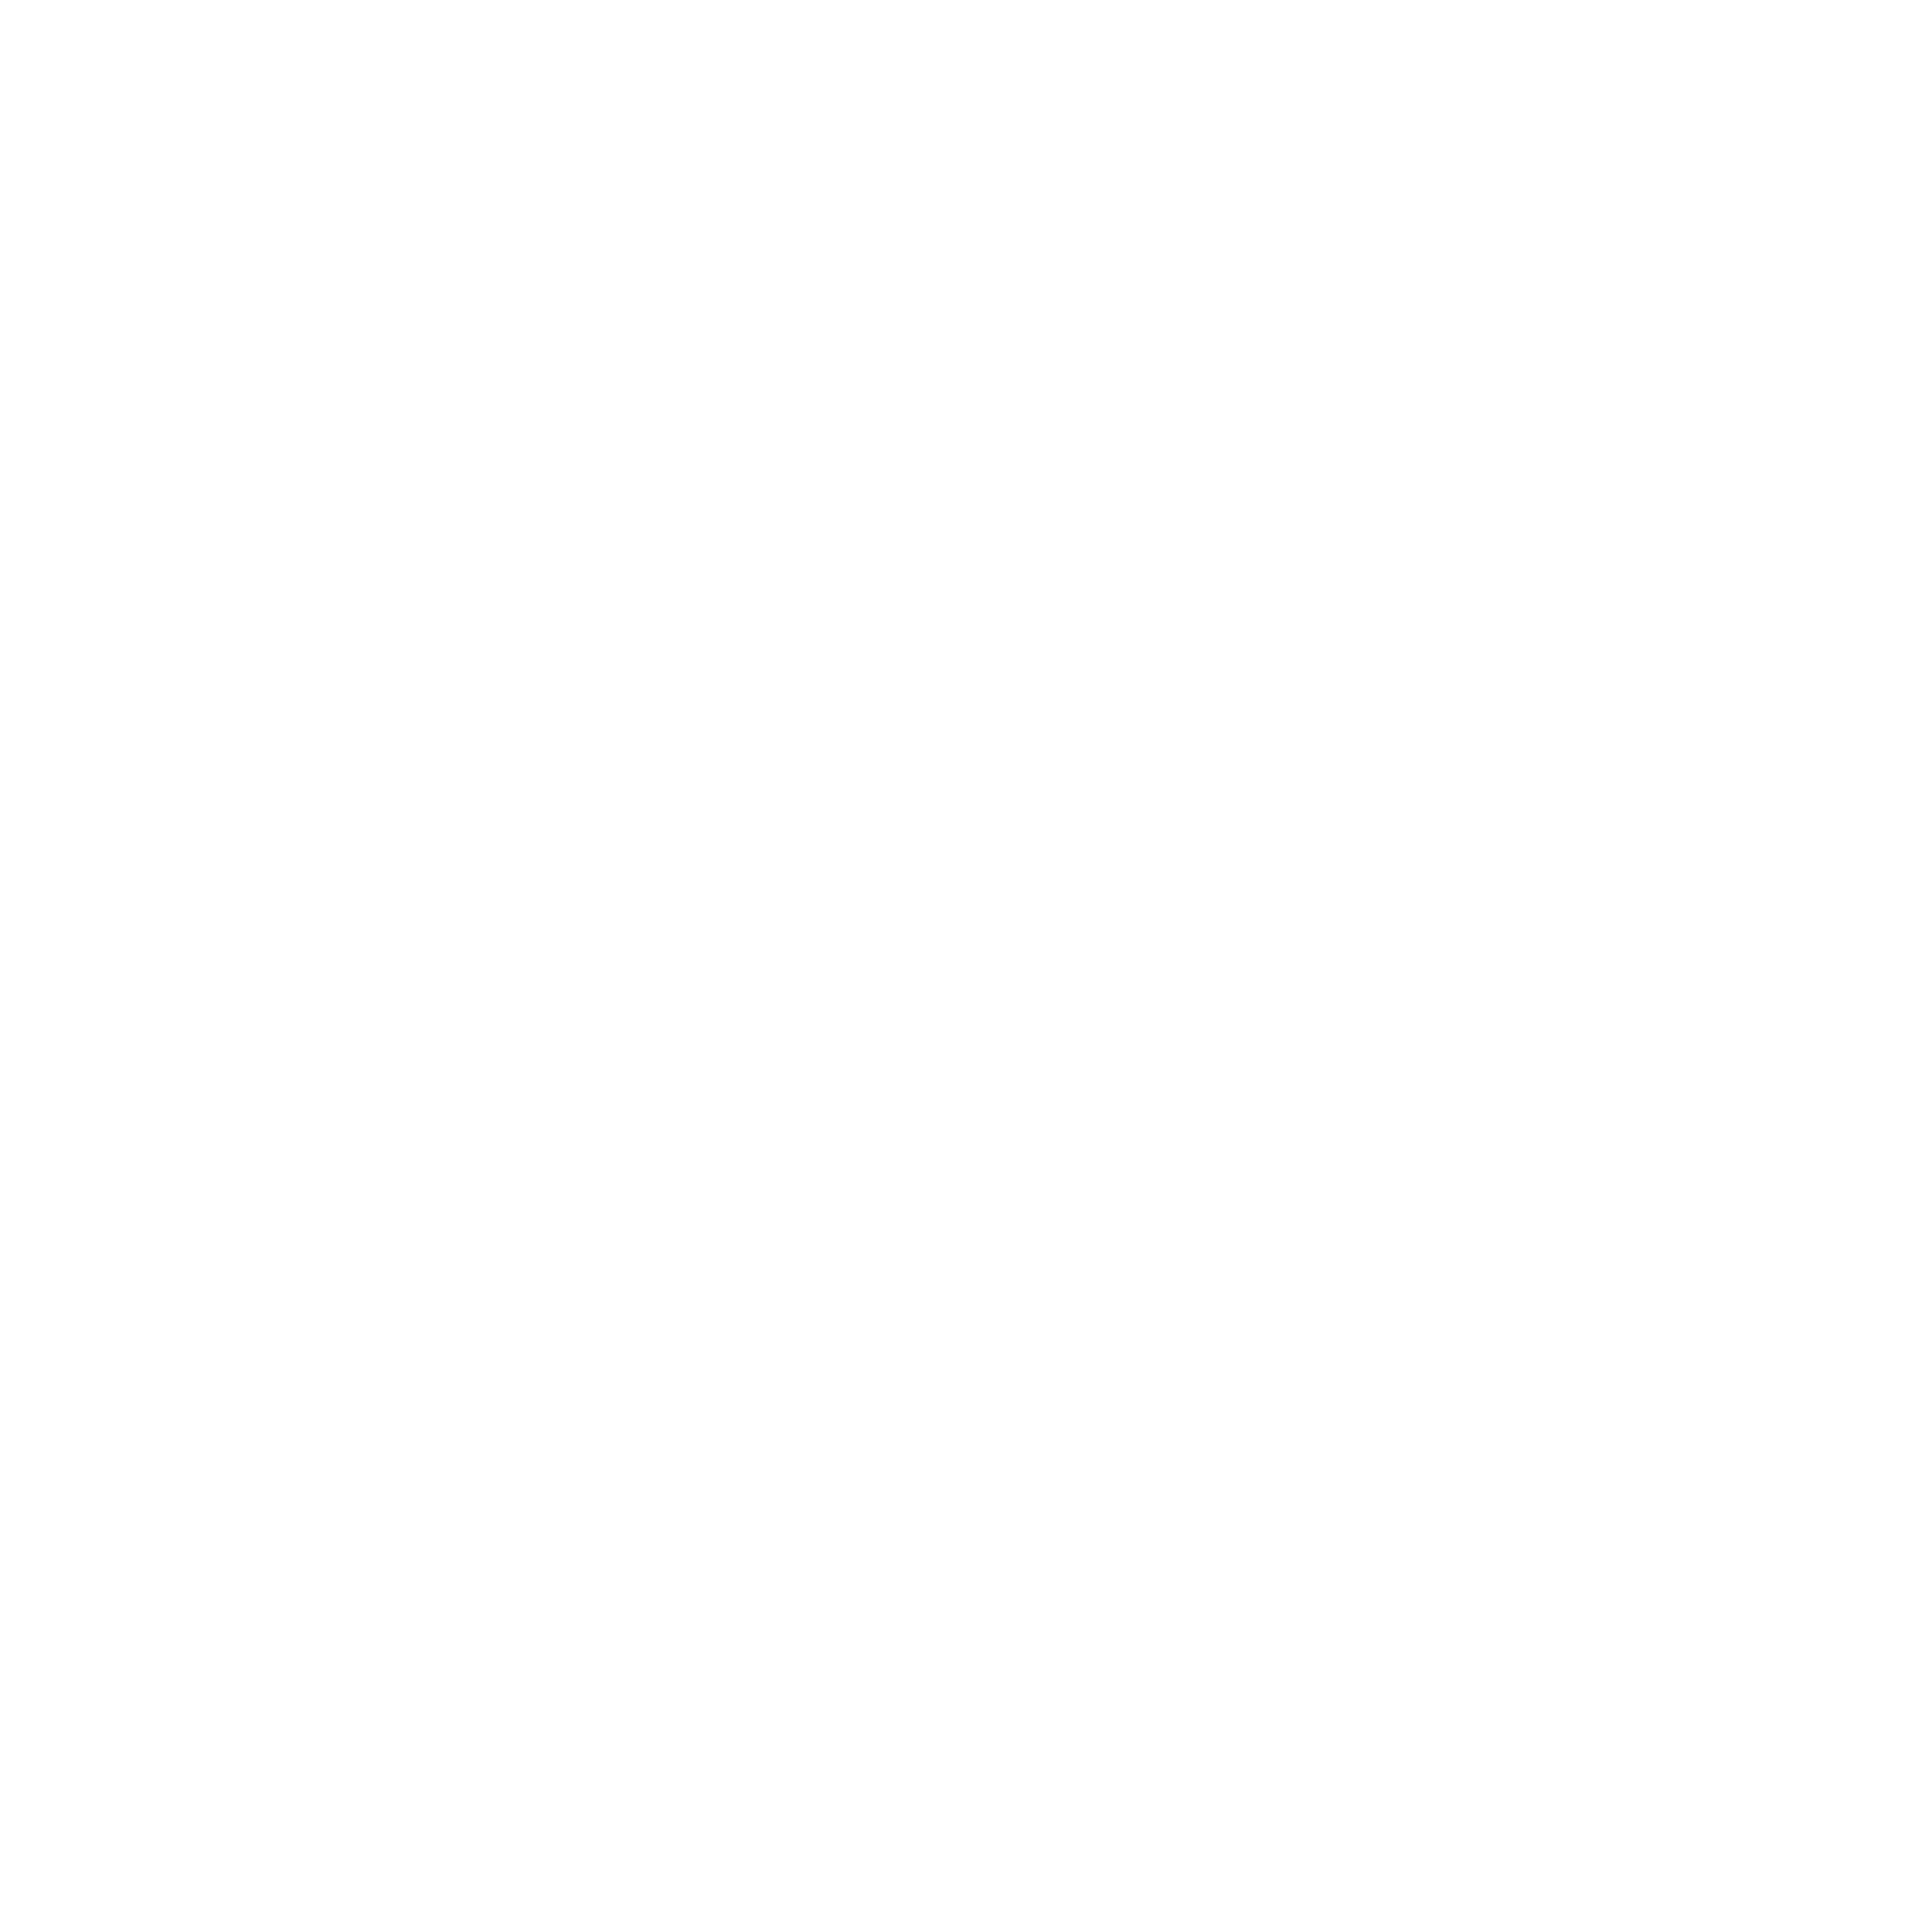

<Figure size 1000x1000 with 0 Axes>

In [3]:
p_range = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
lower = 0.4
upper = 0.5

frames = []

for i in range(len(p_range)-1):
    bins = np.linspace(-1,1,41)
    fig, ax = plt.subplots(1, 1, 
                           figsize=(8, 5))
                           # sharex = True,
                           # gridspec_kw={"hspace": 0.05})

    Bfield = f"B05"
    p_lower = p_range[i]
    p_upper = p_range[i+1]
    esc_mom = (data[Bfield].esc.PiPlus.p >= p_lower) & (data[Bfield].esc.PiPlus.p <= p_upper)
    # det1_mom = (data[Bfield].det1.PiPlus.p >= p_lower) & (data[Bfield].det1.PiPlus.p <= p_upper)
    
    ax = mu.draw_hist(ax, 
                     ak.flatten(data[Bfield].esc.PiPlus.cz[esc_mom]), bins,
                     f'5T: $\\pi^+$ escaped = {ak.count(data[Bfield].esc.PiPlus.cz[esc_mom])}',
                     color = run.COLOR_MAP[Bfield])
    ax.legend(fontsize = 14, loc="upper left")

    # ax[1].set_yscale("log")
    ax.set_xlabel('Cos $\\theta_z$', fontsize=14)
    ax.set_ylabel(r'$N_{\pi}$', fontsize=14)
    
    ax.set_ylim(0,5000)
    
    ax.set_title(f'Angular distributions for pions with {p_lower} < p < {p_upper} GeV/c', fontsize=16)
    
    ax.text(
        0.04, 0.15,
        "Pions escaped the target",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="bottom"
    )
    plt.show()

    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave(
"piplus_cz.gif",
frames,
duration=1000,
loop=0,
)

display(Image(filename="piplus_cz.gif"))

In [13]:
analysis_rootdir = pathlib.Path.cwd()
analysis_rootdir

PosixPath('/mnt/ceph/home/ralharth/fluka/mucol-targetstudy/flukaAnalysis/BfieldStrength')